# 03. Reddit (계획 9단계, 우선순위 최하)

- 2.9GB라 NLP 없이 **티커 언급량**과 **subreddit 활동량**만 봄
- `score`, `n_comments`는 36시간 뒤 값이라 읽지도 않음
- 티커는 `$TICKER`는 모두 인정하고, 맨 대문자 단어는 일반 단어와 겹치지 않는 종목만 인정함
  (NOW, COST, WELL, V, GE, KO, MS 등은 `$`가 있을 때만)
- 첫 실행은 전체 집계에 약 2분 걸리고, 이후엔 캐시를 씀

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import eda_utils as U

U.setup_plot()
pd.set_option("display.float_format", "{:.4f}".format)

panel, cal = U.load_all(reddit=True)
mentions = pd.read_parquet(U.CACHE / "reddit_mentions.parquet")
activity = pd.read_parquet(U.CACHE / "reddit_activity.parquet")
d = panel.dropna(subset=["gap"]).copy()

## 1. 종목별 언급량

### 그림: 로그 축 가로 막대그래프
값이 수십~수만으로 크게 차이 나면 보통 축에서는 작은 값의 막대가 거의 안 보임.
**로그 축은 눈금이 10, 100, 1000처럼 10배씩 늘어나는 축**이라, 크기 차이가 큰 값들을 한 그림에서 비교할 수 있음.

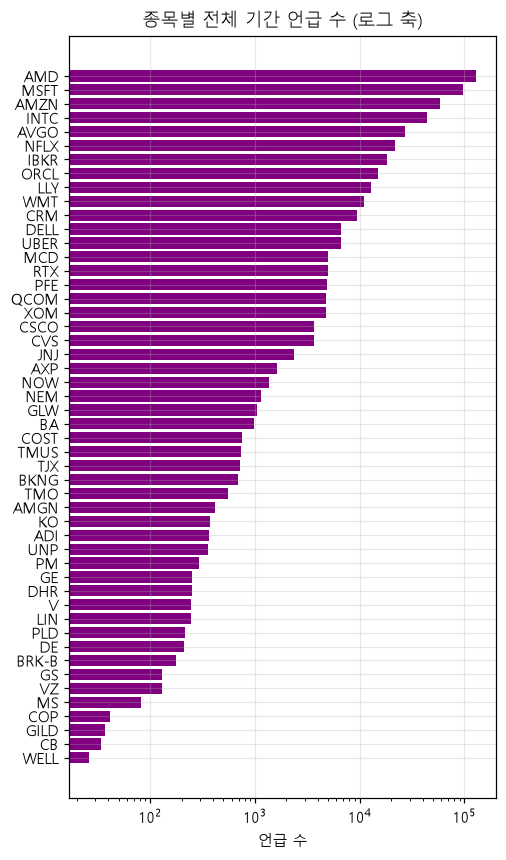

In [2]:
tot = mentions.groupby("symbol")["mentions"].sum().reindex(sorted(panel["symbol"].unique())).fillna(0).sort_values()
fig, ax = plt.subplots(figsize=(5, 9))
ax.barh(tot.index, tot.clip(lower=1), color="purple")
ax.set_xscale("log")
ax.set(title="종목별 전체 기간 언급 수 (로그 축)", xlabel="언급 수")
plt.show()

## 2. subreddit 활동량

### 그림: 시계열 선 그래프 (time series line chart)
가로축이 시간인 선 그래프임. **값이 시간에 따라 어떻게 오르내리는지, 특정 시점에 튀는지**를 봄.
subreddit마다 규모가 달라서 각자의 중앙값으로 나눈 상대값(1 = 평소)으로 그림.

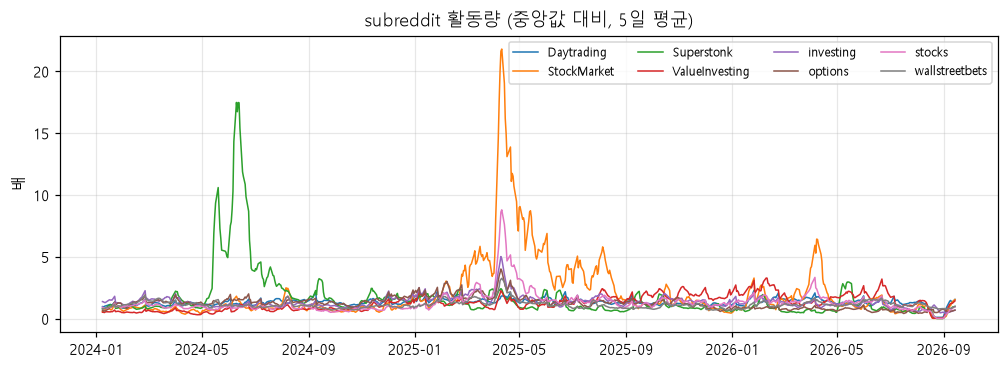

In [3]:
piv = activity.pivot(index="target", columns="sub", values="items")
rel = piv / piv.median()
fig, ax = plt.subplots(figsize=(11, 3.5))
for c in rel.columns:
    ax.plot(rel.index, rel[c].rolling(5).mean(), lw=1, label=c)
ax.set(title="subreddit 활동량 (중앙값 대비, 5일 평균)", ylabel="배")
ax.legend(ncol=4, fontsize=8)
plt.show()

## 3. 언급량 급증과 급등락

구간별 평균 막대그래프(binned bar chart)로 봄. 왼쪽은 언급량이 평소보다 많은 정도(mentions_abn)의 십분위별 급등락 비율임.
언급이 적은 종목에서도 통하는지 보려고 오른쪽은 언급 하위 절반 종목만 따로 그림.

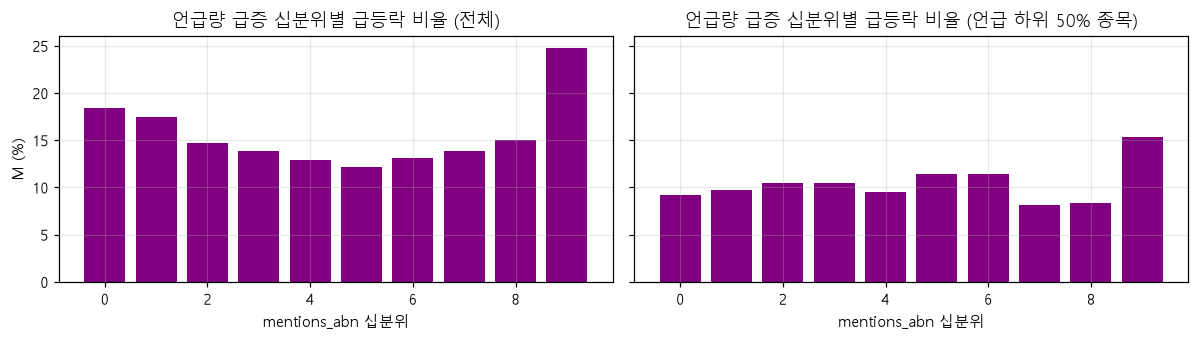

In [4]:
low = tot[tot <= tot.median()].index
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, sub, title in [(axes[0], d, "전체"), (axes[1], d[d["symbol"].isin(low)], "언급 하위 50% 종목")]:
    b = U.binned(sub, "mentions_abn", "M", q=10)
    ax.bar(range(len(b)), b["M"] * 100, color="purple")
    ax.set(title=f"언급량 급증 십분위별 급등락 비율 ({title})", xlabel="mentions_abn 십분위")
axes[0].set_ylabel("M (%)")
plt.tight_layout()
plt.show()

## 4. 시장 분위기: 활동량과 그날의 급등락 종목 비율

### 그림: 산점도 (scatter plot)
점 하나가 **대상일 하루**임. 가로축은 wallstreetbets 활동량(평소 대비), 세로축은 그날 급등락한 종목 비율임.
점들이 오른쪽 위로 몰리면 활동이 많은 날에 시장 전체가 크게 움직인다는 뜻임.

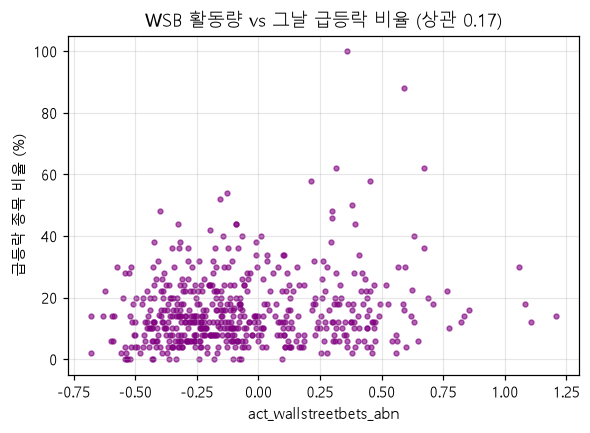

In [5]:
day = d.groupby("target").agg(M=("M", "mean"), act=("act_wallstreetbets_abn", "first")).dropna()
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(day["act"], day["M"] * 100, s=10, alpha=0.6, color="purple")
ax.set(title=f"WSB 활동량 vs 그날 급등락 비율 (상관 {day.corr().iloc[0, 1]:.2f})",
       xlabel="act_wallstreetbets_abn", ylabel="급등락 종목 비율 (%)")
plt.show()

## 5. 빠른 Δscore 확인 (한 구간)

In [6]:
base = ["gap_pct", "abs_gap", "zgap", "gap_rank"]
acts = [c for c in panel.columns if c.startswith("act_")]
split = [("2026-01 기준", (panel["target"] < "2025-12-15").to_numpy(), (panel["target"] >= "2026-01-01").to_numpy())]
U.delta_table(panel, base, {"Reddit 언급": ["mentions_abn"], "Reddit 활동": acts}, split)

,split,group,solo,with_base,base,d_score,flip_rate,big_recall,big_prec
0,2026-01 기준,기준선,0.5101,0.5101,0.5101,0.0000,0.1781,0.5873,0.2720
1,2026-01 기준,Reddit 언급,0.0015,0.5144,0.5101,0.0043,0.2179,0.6449,0.2401
2,2026-01 기준,Reddit 활동,-0.0141,0.4665,0.5101,-0.0436,0.1313,0.4693,0.3048
